In [2]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"   # ← le même que d'habitude
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")
print(X_train.shape, X_val.shape)

Mounted at /content/drive
(3716, 126) (819, 126)


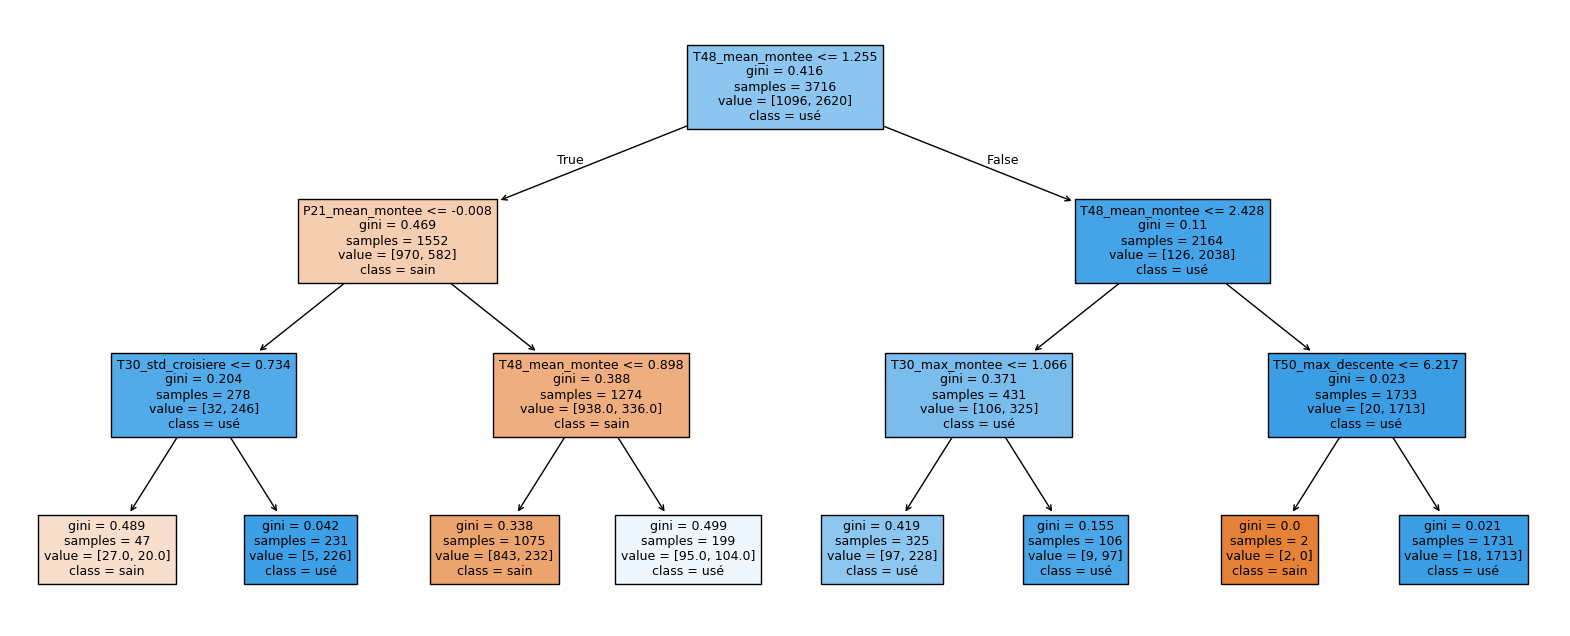

In [2]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

petit_arbre = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(petit_arbre, feature_names=list(X_train.columns),
          class_names=["sain", "usé"], filled=True, fontsize=9)
plt.show()

In [3]:
from sklearn.metrics import f1_score

lignes = []
for profondeur in [2, 4, 8, 16, None]:
    arbre = DecisionTreeClassifier(max_depth=profondeur, random_state=42).fit(X_train, y_train)
    lignes.append({
        "max_depth": str(profondeur),
        "f1_macro_train": f1_score(y_train, arbre.predict(X_train), average="macro"),
        "f1_macro_val": f1_score(y_val, arbre.predict(X_val), average="macro"),
    })
pd.DataFrame(lignes).round(3)

,max_depth,f1_macro_train,f1_macro_val
0,2,0.847,0.851
1,4,0.862,0.834
2,8,0.931,0.829
3,16,0.999,0.799
4,None,1.000,0.787


In [4]:
from sklearn.ensemble import RandomForestClassifier
from aeroguard.evaluation import metriques, taux_par_classe

foret = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
foret.fit(X_train, y_train)

pred = foret.predict(X_val)
proba = foret.predict_proba(X_val)[:, 1]
scores_foret = metriques(y_val, pred, proba)
print({k: round(v, 3) for k, v in {**scores_foret, **taux_par_classe(y_val, pred)}.items()})

{'precision': 0.882, 'rappel': 0.951, 'f1': 0.915, 'f1_macro': 0.844, 'vn': 171, 'fp': 73, 'fn': 28, 'vp': 547, 'pr_auc': 0.985, 'exactitude': 0.877, 'uses_detectes': 0.951, 'sains_reconnus': 0.701}


,feature,importance,description
0,T48_mean_montee,0.091024,T48 moyenne en montée
1,T50_mean_montee,0.071300,T50 moyenne en montée
2,T48_mean_croisiere,0.065104,T48 moyenne en croisière
3,T50_mean_croisiere,0.040681,T50 moyenne en croisière
4,T50_mean_descente,0.039156,T50 moyenne en descente
5,T48_mean_descente,0.034857,T48 moyenne en descente
6,T24_mean_montee,0.031542,T24 moyenne en montée
7,T50_max_montee,0.022650,T50 maximum en montée
8,Nc_mean_montee,0.020694,Nc moyenne en montée
9,T48_max_montee,0.020327,T48 maximum en montée


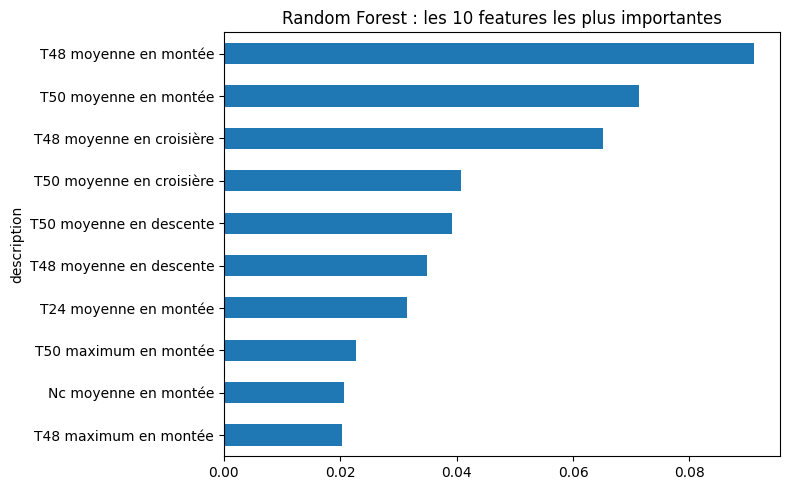

In [5]:
from aeroguard.explication import importances_triees

top = importances_triees(foret.feature_importances_, X_train.columns, n=10)
display(top)

top.iloc[::-1].plot.barh(x="description", y="importance", legend=False, figsize=(8, 5))
plt.title("Random Forest : les 10 features les plus importantes")
plt.tight_layout()
plt.show()

In [6]:
from aeroguard.evaluation import ajouter_au_leaderboard

cles = ["precision", "rappel", "f1", "f1_macro", "pr_auc", "fp", "fn"]
ajouter_au_leaderboard(f"{DOSSIER}/results/leaderboard.csv", "random_forest",
                       {k: scores_foret[k] for k in cles})
pd.read_csv(f"{DOSSIER}/results/leaderboard.csv").sort_values("f1_macro", ascending=False)

,modele,f1_macro,pr_auc,rappel,precision,f1,fp,fn
2,logistique,0.886000,0.987000,0.932000,0.932000,0.932000,39.0,39.0
3,logistique_balanced,0.882083,0.986936,0.873043,0.974757,0.921101,NaN,NaN
4,random_forest,0.843745,0.984866,0.951304,0.882258,0.915481,73.0,28.0
1,copieur_knn,0.763000,0.903000,0.843000,0.866000,0.855000,75.0,90.0
0,bete,0.412000,0.702000,1.000000,0.702000,0.825000,244.0,0.0
